**Objective**: The objective of this lesson is to learn the fundamental techniques for handling missing data, which is one of the most common and critical steps in any data analysis project. By the end of this session, you will be able to use the pandas library to find, analyze, and correct different types of missing values in a DataFrame!

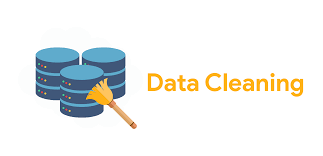

# Data cleaning
Data cleaning is an essential task in any data analysis project. It involves **identifying and handling** inconsistencies, errors, missing values, and outliers in data to ensure the accuracy and reliability of analysis results.

In this context, pandas provides a wide range of methods and functions that facilitate data cleaning tasks. These include methods for data filtering, data manipulation, and data transformation. In addition, pandas provides support for missing data with tools for imputation and interpolation, which allows the user to replace missing values with estimated values based on the available data.

So what should you take away from this? **Cleaning data(frames in pandas) is a important task that should be performed in any data analysis project.**

## Identifying missing values

Before we can clean our data, we have to perform a diagnosis to find out what's wrong with it.

The most common problem you'll encounter is missing data.

In pandas, our primary diagnostic tools are the .isnull() and .sum() methods, which help us locate and count missing values.




In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Create a sample DataFrame representing sensor readings from a building
# This data includes missing values from a sensor error and a system being offline.
df = pd.DataFrame({
    'Room_ID': ['Office_101', 'Conf_203', 'Lobby_1', 'Lab_310'],
    'Temperature_C': [21.5, 22.0, np.nan, 23.1],  # A sensor failed to report a temperature
    'CO2_ppm': [550, 780, 620, np.nan],            # The CO2 sensor also failed
    'HVAC_Status': ['On', 'On', 'On', 'Offline']  # This system was offline, not necessarily a standard 'NaN'
})

print("Original Building Sensor Data:")
print(df)

**How Does This Happen in Architectural Engineering?**
Missing data isn't just a theoretical problem; it happens constantly in AE projects. Here are a few common scenarios:

* **Sensor Malfunctions:** A building management system (BMS) has hundreds of sensors measuring temperature, humidity, CO₂, and energy use. If a sensor temporarily goes offline or fails, it will create gaps (i.e., missing values) in your time-series data.

* **Manual Data Entry Errors:** During a building audit or post-occupancy evaluation, a technician might forget to write down a measurement, or someone transcribing handwritten notes into a spreadsheet might skip a field. This often results in blank cells in your dataset.

* **Incomplete Surveys:** When studying occupant comfort, you might send out surveys asking people to rate temperature, lighting, and noise levels. If a person skips a question, that entry becomes a missing value in your survey results.

**Why Is Ignoring Missing Data So Bad?**
Failing to identify and handle these gaps can lead to seriously flawed conclusions. If you just ignore the missing data and proceed with your analysis, you might:

* **Underestimate Energy Consumption:** If your energy meter sensor was offline for a few days, calculating the average or total energy use from the remaining data would give you a number that is artificially low, making the building seem more efficient than it really is.

* **Get Biased Results:** In an occupant comfort survey, if all the people who were uncomfortably warm skipped the temperature question, your results would be biased to show that occupants are generally satisfied, which is completely wrong.

* **Break Your Models:** Many statistical analyses and machine learning models will simply fail to run or will produce an error if they encounter missing data.

By first identifying where and how much data is missing, you take the first step toward creating an accurate and reliable dataset. Now, let's look at the code to do just that!!

In [ ]:
# lets code together
# identify missing values using isnull() method



In the output, we can see that the missing values are represented as True.

To count the number of missing values in each column of a DataFrame, we can use the sum() method on the Boolean DataFrame returned by the isnull() method. The sum() method treats True as 1 and False as 0, so by summing the Boolean DataFrame, we can count the number of True values in each column.

Here is an example of how to use the sum() method to count the number of missing values in each column of a DataFrame:

In [ ]:
# lets code together

# count missing values in each column


In the output, we can see that there is one missing value in each column of the DataFrame.

Let's try this on a dataset about HVAC systems in different buildings.

The file has five columns: Building Name, HVAC Type, Energy Efficiency, Last Maintenance Date, and Maintenance Cost.

* Building Name column contains the names of the buildings
* HVAC Type column contains the type of HVAC system in each building,
* Energy Efficiency column contains the energy efficiency rating of each building,
* Last Maintenance Date column contains the date of the last maintenance for each building's HVAC system (some dates are missing),
* Maintenance Cost column contains the cost of the last maintenance for each building's HVAC system (some costs are missing).

In [ ]:
url = 'https://pennstateoffice365-my.sharepoint.com/:x:/g/personal/rjn5308_psu_edu/ERXN7J_cmRFGsFbGdwa6w1EBkK08r7erXPGkr8TkFQpasQ?e=PVehhK'

# your turn, read in the data from this url


 Let's use the isnull() method to identify missing values in the DataFrame, and the sum() method to count the number of missing values in each column.

  After, display the number of missing values in each column using the print() function.

In [ ]:
# your turn



The output shows that there are 2 missing values in the Last Maintenance Date column, and 1 missing value in the Maintenance Cost column.

## Removing rows with missing values

The **dropna() method** is a Pandas DataFrame method that is used to remove missing values from a DataFrame.

By default, dropna() removes any row that contains at least one missing value (i.e., NaN). However, you can specify the axis and threshold values to control which rows and columns to remove. The inplace parameter can be set to True to modify the DataFrame in place, without creating a new copy.

Here's the syntax of the dropna() method:



```
DataFrame = DataFrame.dropna(axis=0, how='any', thresh=None, subset=None)

```

Here's what each parameter means:

* axis: specifies the axis along which to remove missing values. By default, it's set to 0, which means that rows with missing values are removed.
* how: specifies how to drop rows or columns based on missing values. By default, it's set to 'any', which means that any row or column containing at least one missing value will be removed. Alternatively, it can be set to 'all', which means that only rows or columns containing all missing values will be removed.
* thresh: specifies the minimum number of non-missing values required for a row or column to be kept. For example, if thresh=3, then only rows or columns containing at least three non-missing values will be kept.
* subset: specifies a list of column names to consider when dropping missing values. Only rows or columns containing missing values in the specified columns will be removed.

In summary, the dropna() method is a convenient and powerful method to remove missing values from a Pandas DataFrame. It provides several parameters to control how to drop rows or columns based on missing values.

Let's try it on our data!

In [ ]:
# remove rows with missing values using dropna() method
hvac_df = hvac_df.dropna()

# display the cleaned DataFrame
print(hvac_df)

You can also remove rows or columns with missing values based on specific criteria. For example, you can drop rows with missing values in a specific column using the following code:



```
df = df.dropna(subset=['column_name'])

```
This code drops any row in the DataFrame df where the value in the column_name column is missing. The inplace=True parameter modifies the DataFrame in place, without creating a new copy.




## Filling in missing values

The fillna() method is a Pandas DataFrame method used to fill missing values in a DataFrame with a specific value or with values derived from other parts of the DataFrame. The method returns a new DataFrame with the missing values filled or a copy of the original DataFrame with the missing values filled.

The fillna() method is a flexible method that allows you to fill missing values with a variety of techniques, including:

* Constant value: fill missing values with a constant value.
* Mean, median, or mode: fill missing values with the mean, median, or mode value of the column.
* Forward or backward fill: fill missing values with the last known value (forward fill) or the next known value (backward fill) in the column.
* Interpolation: fill missing values with values interpolated from other values in the column.

Here's the syntax of the fillna() method:

```
DataFrame = DataFrame.fillna(value=None, method=None, axis=None limit=None)
```

Here's what each parameter means:

* value: specifies the value to use to fill the missing values. It can be a scalar value, a dictionary, a Series, or a DataFrame.
* method: specifies the interpolation method to use when filling missing values. It can be 'ffill' for forward fill, 'bfill' for backward fill, or 'interpolate' for interpolation.
* axis: specifies the axis along which to fill the missing values. By default, it's set to 0, which means that missing values in columns will be filled.
inplace: specifies whether to modify the DataFrame in place (i.e., without creating a new copy).
* limit: specifies the maximum number of consecutive missing values to fill. By default, there is no limit.

In [ ]:
# read the CSV file into a Pandas DataFrame again so we can start fresh
hvac_df = pd.read_csv('hvac.csv')
print(hvac_df)

In [ ]:
# fill missing values with the mean value of each column
hvac_df = hvac_df.fillna(hvac_df.mean(numeric_only=True)) # see what happens if you leave out the numeric_only!

# display the cleaned DataFrame
print(hvac_df)


We then used the fillna() method to fill missing values in the DataFrame with the mean value of each column. The cleaned DataFrame with the missing values filled with the mean value of each column is then displayed using the print() function. The output shows that the missing values in the Maintenance Cost column have been filled with the mean value of each column.

Filling the missing values with the mean value of the Last Maintenance Date column is not appropriate since it's a date column.

Instead, we can fill the missing values in the Last Maintenance Date column with the most recent date available, or with the next closest date using interpolation.

In [ ]:
# fill missing values in the Last Maintenance Date column with the most recent date
hvac_df['Last Maintenance Date'] = hvac_df['Last Maintenance Date'].fillna(method='ffill')
# display the cleaned DataFrame
print(hvac_df)

**SIDE NOTE FOR THE CURIOUS:**
A Note on FutureWarning: What It Is and Why You Shouldn't Ignore It(!!)
You might have noticed that when you ran the last piece of code, you got a message that started with FutureWarning. Don't panic! This is not an error. Your code still worked perfectly.

So, what is it? Do we need to care about it?

A FutureWarning is a friendly heads-up from the developers of a library (in this case, pandas). It’s their way of telling you, "The way you're doing this works for now, but we've created a better, clearer way to do it. In a future version of our library, the old way will stop working."

Think of it like a road sign that says "Detour Ahead in 2 Miles." You can keep driving for now, but you're being warned that you'll need to change your route soon.

Why Do Libraries Do This?
Libraries like pandas are constantly evolving. Developers want to make them faster, more efficient, and easier to read. In this specific case, they decided that having separate, direct methods for forward-filling and back-filling was clearer than nesting that instruction inside the more general .fillna() method.

Let's Break Down This Specific Warning:
The warning message is very helpful:

`FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.`

This tells us exactly what to do.


In [ ]:
# This is the modern, future-proof way to write it
hvac_df['Last Maintenance Date'].ffill()

Instead of a general "fill" command with a specific "method," you use a command that is the method itself: .ffill() (forward-fill).

The key takeaway from this is that you should always pay attention to FutureWarning messages. They are a great way to keep your coding skills up-to-date and ensure that the code you write today will still work tomorrow!!

**Back to our example:**
In this example, we used the fillna() method with the method='ffill' parameter to fill missing values in the Last Maintenance Date column with the most recent date available in the column. The cleaned DataFrame with the missing values filled with the most recent date is then displayed using the print() function.

Here's an example code snippet that demonstrates how to use the fillna() method with interpolation to fill missing values in the Maintenance Cost column

In [ ]:
# read the CSV file into a Pandas DataFrame again so we can start fresh
hvac_df = pd.read_csv('hvac.csv')
# display the cleaned DataFrame
print(hvac_df)

In [ ]:
# fill missing values in the Maintenance Cost column using interpolation
hvac_df['Maintenance Cost'] = hvac_df['Maintenance Cost'].interpolate(method='linear')

# display the cleaned DataFrame
print(hvac_df)

In this example, we used the fillna() method with the interpolate() method to fill missing values in the Maintenance Cost column using linear interpolation. The cleaned DataFrame with the missing values filled with interpolated values is then displayed using the print() function. The output shows that the missing values in the Maintenance Cost column have been filled with interpolated values.

## Handling other types of missing data

In addition to NaN values, which are typically used to represent missing or undefined numerical data, there are other types of missing data that may appear in a dataset, such as missing values, NA, blanks, and dashes.

Missing values can take different forms depending on the data type and the source of the data. For example, missing values in a numerical column may be represented as NaN, None, -999, or other special values depending on the context. Similarly, missing values in a categorical column may be represented as NA, "", "Unknown", or other values depending on the context.

In Pandas, missing values can be represented using different types, such as None, NaN, NaT (Not a Time), and NaT (Not a Timedelta), depending on the data type.

For example, if a dataset contains missing values represented as blanks or dashes, you can use the replace() method to replace these values with NaN values, which Pandas recognizes as missing values. Here's an example:

```
# replace blanks and dashes with NaN
df = df.replace(['', '-'], pd.NA)
```

In this example, we used the replace() method to replace all blank and dash values in the DataFrame df with NaN values using the pd.NA constant.

Here's an example code snippet that creates a Pandas DataFrame about encouraging occupants to adopt energy-saving behaviors. This DataFrame includes some missing data represented as NA, blanks, and dashes:

In [ ]:
import numpy as np

# create a dictionary with data about energy-saving behaviors
data = {
    'Building Name': ['Building A', 'Building B', 'Building C', 'Building D', 'Building E', 'Building F'],
    'Light Off Behavior': ['Turn off all lights when leaving a room', 'NA', 'Leave some lights on for security purposes', '-', '', np.nan],
    'Electronics Behavior': ['Unplug electronics when not in use', 'Turn off electronics when not in use', '-', '', '', np.nan],
    'Energy Savings': [10, 20, 5, 15, np.nan, 25]
}

# create a Pandas DataFrame from the dictionary
df = pd.DataFrame(data)

# display the DataFrame
print(df)


In [ ]:
# replace NA, blanks, and dashes with NaN
df = df.replace(['NA', '', '-'], np.nan)

# display the cleaned DataFrame
print(df)

In this example, we used the replace() method to replace NA, blanks, and dashes in the DataFrame df with NaN values using the np.nan constant. The cleaned DataFrame with missing data represented as NaN values is then displayed using the print() function. The output shows that missing values represented as NA, blanks, and dashes have been replaced with NaN values.

And now we can decide to drop the NaN values or fill them with one of the methods above.

Try dropping all the rows that have a NaN and then print the result. Before you code it, try to look at your data and guess what the output will be.

In [ ]:
df = df.dropna()
print(df)

Turns out just dropping everything that has a na though gets rid of most of our data! So you will want to be careful with that! We will talk about more advanced ways to filter data net class!

---
## 📋 Today's In-Class Assignment

**Your in-class assignment for today is the dropna() exercise above** -- the cell where you dropped all rows containing a NaN and printed the result. Submit it to Canvas before you leave.

To submit:
1. Make sure your code in that cell runs without errors (press Shift+Enter to run it)
2. Take a screenshot of your code and its output
3. Go to the module on Canvas that this lesson was part of and find today's in-class assignment, due at midnight
4. Upload your screenshot

*If you have multiple screenshots, combine them into a single PDF before uploading.*

**You only need to show that you tried; this is graded on effort, not perfection.**

---

## Key Takeaways from Today's lesson:



**Missing data comes in many forms.** While pandas recognizes NaN and None by default, real-world datasets often use other placeholders like blanks, dashes (-), or text strings like 'NA' to represent missing information.



**Always standardize missing values first!** Before you can effectively use pandas methods like .dropna() or .fillna(), you should first use .replace() to convert all non-standard placeholders into a format pandas recognizes, such as np.nan.



**You have two main strategies: drop or fill.** Your primary options for handling missing data are to either remove the rows/columns containing them with .dropna() or to fill them with an estimated value using .fillna(). Dropping is simpler but results in data loss, while filling preserves your data but requires making an educated guess.


**The best filling strategy depends on the data's context.** There is no single best way to fill missing values; the choice depends on the data type and what makes the most sense.

* For numerical columns, filling with the mean() is a common starting point.


* For dates or sequential data, using the last valid observation with forward-fill (method='ffill') is often more logical than calculating a mean.


* When a numerical trend exists, .interpolate() can provide a more accurate estimate than a simple average.